# Figure 1

Taxonomic treemap and genus-category UpSet plot.


In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
import copy
import re
import shutil
import subprocess
from xml.etree import ElementTree as ET

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG, display


PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "assets").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATABASE_PATH = PROJECT_DIR / "local_data" / "ani_microbial_eukaryotes.duckdb"
ASSETS_DIR = PROJECT_DIR / "assets"
OUTPUT_DIR = ASSETS_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

figure1_panel_directory = TemporaryDirectory()
FIGURES_DIR = Path(figure1_panel_directory.name)

PUBLICATION_FONT = "Nimbus Sans"
PUBLICATION_FONT_STACK = [
    PUBLICATION_FONT,
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
    "sans-serif",
]
PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": PUBLICATION_FONT_STACK,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)


In [2]:
# Prepare the retained genomes used by the treemap.
figure1_tax_levels = ["domain", "phylum", "class", "order", "family", "genus", "species"]
figure1_rank_columns = {level: f"{level}_2026_09_01" for level in figure1_tax_levels}
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    figure1_genomes = con.execute("SELECT * FROM genomes").fetchdf()
figure1_genomes = figure1_genomes.rename(
    columns={column: level for level, column in figure1_rank_columns.items()}
)
for col in figure1_genomes.select_dtypes(include="object"):
    figure1_genomes[col] = figure1_genomes[col].str.strip()

figure1_treemap_threshold = 50
figure1_binned_genomes = figure1_genomes.copy()
for level in figure1_tax_levels:
    figure1_binned_genomes[level] = figure1_binned_genomes[level].fillna(f"{level}_unresolved")
    low_count = figure1_binned_genomes[level].value_counts()
    low_count = low_count[low_count <= figure1_treemap_threshold].index
    figure1_binned_genomes[level] = figure1_binned_genomes[level].replace(low_count, f"{level}_other")


In [3]:
# Treemap plot
from matplotlib.colors import to_rgb
from matplotlib.patches import Rectangle

FIG1_SET2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]


def figure1_squarify(items, x, y, dx, dy):
    items = [item.copy() for item in items if item["value"] > 0]
    total = sum(item["value"] for item in items)
    if not items or total <= 0 or dx <= 0 or dy <= 0:
        return []
    area = dx * dy
    for item in items:
        item["area"] = item["value"] * area / total

    def worst_ratio(row, side):
        if not row:
            return float("inf")
        row_area = sum(item["area"] for item in row)
        max_area = max(item["area"] for item in row)
        min_area = min(item["area"] for item in row)
        if min_area <= 0 or row_area <= 0 or side <= 0:
            return float("inf")
        return max((side**2 * max_area) / (row_area**2), (row_area**2) / (side**2 * min_area))

    def layout_row(row, x, y, dx, dy):
        rects = []
        row_area = sum(item["area"] for item in row)
        if dx >= dy:
            row_h = row_area / dx
            cursor = x
            for item in row:
                rect_w = item["area"] / row_h
                rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": row_h})
                cursor += rect_w
            return rects, x, y + row_h, dx, dy - row_h
        row_w = row_area / dy
        cursor = y
        for item in row:
            rect_h = item["area"] / row_w
            rects.append({**item, "x": x, "y": cursor, "dx": row_w, "dy": rect_h})
            cursor += rect_h
        return rects, x + row_w, y, dx - row_w, dy

    remaining = items[:]
    row = []
    rects = []
    while remaining:
        candidate = remaining[0]
        side = min(dx, dy)
        if not row or worst_ratio(row + [candidate], side) <= worst_ratio(row, side):
            row.append(candidate)
            remaining.pop(0)
        else:
            laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
            rects.extend(laid_out)
            row = []
    if row:
        laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
        rects.extend(laid_out)
    return rects


def figure1_luminance(color):
    r, g, b = to_rgb(color)
    return 0.299 * r + 0.587 * g + 0.114 * b


def figure1_draw_text(ax, patch, x, y, text, fontsize, color="#223", weight="normal"):
    txt = ax.text(x, y, text, fontsize=fontsize, color=color, va="top", ha="left", weight=weight, clip_on=True)
    txt.set_clip_path(patch)
    return txt


def figure1_draw_fitted_label(ax, patch, rect, label, value, max_fontsize, color="#1f2430"):
    renderer = ax.figure.canvas.get_renderer()
    patch_box = patch.get_window_extent(renderer=renderer)
    usable_width = max(patch_box.width - 8, 0)
    usable_height = max(patch_box.height - 8, 0)

    if label.endswith("_other"):
        separator = "\n" if usable_height >= 30 else " "
        text, rotation = f"Other{separator}{value}", 0
    elif usable_height < 30:
        text, rotation = f"{label}  {value}", 0
    else:
        text, rotation = f"{label}\n{value}", 0

    txt = ax.text(
        rect["x"] + rect["dx"] / 2,
        rect["y"] + rect["dy"] / 2,
        text,
        color=color,
        ha="center",
        va="center",
        rotation=rotation,
        linespacing=0.9,
        clip_on=True,
    )
    txt.set_clip_path(patch)
    for font_size in np.arange(max_fontsize, 4.4, -0.5):
        txt.set_fontsize(font_size)
        text_box = txt.get_window_extent(renderer=renderer)
        if text_box.width <= usable_width and text_box.height <= usable_height:
            return txt
    txt.remove()
    return None


def figure1_top_level_rects(phylum_counts, width=1.0, height=1.0):
    counts = phylum_counts.sort_values(ascending=False)
    total = counts.sum()
    largest = counts.index[0]
    largest_width = counts.iloc[0] / total
    rects = [{"label": largest, "value": counts.iloc[0], "x": 0, "y": 0, "dx": width * largest_width, "dy": height}]
    remaining = counts.iloc[1:]
    y_cursor = 0
    x_right = width * largest_width
    dx_right = width - x_right
    remaining_total = remaining.sum()
    for label, value in remaining.items():
        rect_h = height * value / remaining_total
        rects.append({"label": label, "value": value, "x": x_right, "y": y_cursor, "dx": dx_right, "dy": rect_h})
        y_cursor += rect_h
    return rects


def figure1_split_vertical(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = y
    for item in items:
        rect_h = dy * item["value"] / total
        rects.append({**item, "x": x, "y": cursor, "dx": dx, "dy": rect_h})
        cursor += rect_h
    return rects


def figure1_split_horizontal(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = x
    for item in items:
        rect_w = dx * item["value"] / total
        rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": dy})
        cursor += rect_w
    return rects


def figure1_child_rects(phylum, genus_counts, x, y, dx, dy):
    counts = genus_counts.sort_values(ascending=False)
    items = [{"label": genus, "value": int(value)} for genus, value in counts.items()]
    values = {item["label"]: item["value"] for item in items}

    if dx < 0.35 and len(items) > 1:
        return figure1_split_vertical(items, x, y, dx, dy)

    if phylum == "Ascomycota" and {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other", "Penicillium"}.issubset(values):
        rects = []
        left_items = [
            {"label": "Saccharomyces", "value": values["Saccharomyces"]},
            {"label": "Fusarium", "value": values["Fusarium"]},
        ]
        left_value = sum(item["value"] for item in left_items)
        total_value = sum(values.values())
        left_dx = dx * left_value / total_value
        rects.extend(figure1_split_vertical(left_items, x, y, left_dx, dy))

        right_x = x + left_dx
        right_dx = dx - left_dx
        right_total = total_value - left_value
        top_items = [
            {"label": "Aspergillus", "value": values["Aspergillus"]},
            {"label": "genus_other", "value": values["genus_other"]},
        ]
        top_value = sum(item["value"] for item in top_items)
        top_dy = dy * top_value / right_total
        rects.extend(figure1_split_horizontal(top_items, right_x, y, right_dx, top_dy))

        bottom_y = y + top_dy
        bottom_dy = dy - top_dy
        bottom_labels = [item["label"] for item in items if item["label"] not in {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other"}]
        bottom_total = sum(values[label] for label in bottom_labels)
        pen_dx = right_dx * values["Penicillium"] / bottom_total
        rects.append({"label": "Penicillium", "value": values["Penicillium"], "x": right_x, "y": bottom_y, "dx": pen_dx, "dy": bottom_dy})

        small_labels = [label for label in bottom_labels if label != "Penicillium"]
        small_items = [{"label": label, "value": values[label]} for label in small_labels]
        rects.extend(figure1_squarify(small_items, right_x + pen_dx, bottom_y, right_dx - pen_dx, bottom_dy))
        return rects

    if len(items) == 1:
        return [{**items[0], "x": x, "y": y, "dx": dx, "dy": dy}]
    if len(items) == 2:
        if phylum in {"Apicomplexa", "Oomycota"} or dx < dy:
            return figure1_split_vertical(items, x, y, dx, dy)
        return figure1_split_horizontal(items, x, y, dx, dy)
    return figure1_squarify(items, x, y, dx, dy)


def plot_figure1_treemap(ax, binned_genomes):
    unique_phyla = list(binned_genomes["phylum"].drop_duplicates())
    phylum_colors = {phy: FIG1_SET2[i % len(FIG1_SET2)] for i, phy in enumerate(unique_phyla)}
    phylum_counts = binned_genomes["phylum"].value_counts()
    treemap_width = 1.92
    treemap_height = 1.0
    treemap_area = treemap_width * treemap_height
    padding = 0.008

    ax.set_xlim(0, treemap_width)
    ax.set_ylim(treemap_height, 0)
    ax.axis("off")

    for phylum_rect in figure1_top_level_rects(phylum_counts, width=treemap_width, height=treemap_height):
        phylum = phylum_rect["label"]
        color = phylum_colors[phylum]
        parent_patch = Rectangle(
            (phylum_rect["x"], phylum_rect["y"]),
            phylum_rect["dx"],
            phylum_rect["dy"],
            facecolor=color,
            edgecolor="0.18",
            linewidth=1.1,
            alpha=0.92,
        )
        ax.add_patch(parent_patch)
        phylum_area_frac = (phylum_rect["dx"] * phylum_rect["dy"]) / treemap_area
        figure1_draw_text(
            ax,
            parent_patch,
            phylum_rect["x"] + padding,
            phylum_rect["y"] + padding,
            "Other" if str(phylum).endswith("_other") else str(phylum),
            fontsize=max(8, min(13, 7 + 10 * np.sqrt(phylum_area_frac))),
            color="#17301f" if figure1_luminance(color) > 0.58 else "white",
            weight="bold",
        )

        header_h = min(0.055, phylum_rect["dy"] * 0.20)
        inner_x = phylum_rect["x"] + padding
        inner_y = phylum_rect["y"] + header_h
        inner_dx = max(phylum_rect["dx"] - 2 * padding, 0)
        inner_dy = max(phylum_rect["dy"] - header_h - padding, 0)
        genus_counts = binned_genomes.loc[binned_genomes["phylum"] == phylum, "genus"].value_counts().sort_values(ascending=False)

        for genus_rect in figure1_child_rects(phylum, genus_counts, inner_x, inner_y, inner_dx, inner_dy):
            child_patch = Rectangle(
                (genus_rect["x"], genus_rect["y"]),
                genus_rect["dx"],
                genus_rect["dy"],
                facecolor=color,
                edgecolor="0.20",
                linewidth=0.9,
                alpha=0.82,
            )
            ax.add_patch(child_patch)
            rect_area_frac = (genus_rect["dx"] * genus_rect["dy"]) / treemap_area
            if rect_area_frac >= 0.004:
                font_size = float(np.clip(6.5 + 18 * np.sqrt(rect_area_frac), 7, 15))
                label = str(genus_rect["label"])
                figure1_draw_fitted_label(
                    ax,
                    child_patch,
                    genus_rect,
                    label,
                    genus_rect["value"],
                    max_fontsize=font_size,
                    color="#1f2430",
                )


fig, ax_tree = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.105, right=0.975, top=0.955, bottom=0.075)
fig.canvas.draw()
plot_figure1_treemap(ax_tree, figure1_binned_genomes)
fig.savefig(FIGURES_DIR / "treemap.svg", format="svg", bbox_inches="tight", metadata={"Date": None})
fig.savefig(FIGURES_DIR / "treemap.png", dpi=300, bbox_inches="tight")
plt.close(fig)


In [4]:
# Prepare the existing UpSet inputs.
figure1_genera = pd.read_csv(ASSETS_DIR / "genera_classification_sources_environmental.csv")
figure1_genera.columns = [col.strip().lower() for col in figure1_genera.columns]
figure1_genera["genus"] = figure1_genera["genus"].str.strip()

with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    retained_genomes = con.execute(
        "SELECT genus_2024_05_01 FROM genomes"
    ).fetchdf()
retained_genus_counts = (
    retained_genomes["genus_2024_05_01"]
    .str.strip()
    .value_counts()
    .rename_axis("genus")
    .rename("count")
    .reset_index()
)
figure1_genera = (
    figure1_genera.drop(columns="count", errors="ignore")
    .merge(retained_genus_counts, on="genus", how="inner")
)

figure1_base_cats = ["industry", "agriculture", "public_health"]
figure1_label_map = {
    "industry": "Industry",
    "agriculture": "Agriculture",
    "public_health": "Public Health",
    "other": "Other",
}


def figure1_to01(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return (numeric.fillna(0) > 0).astype(int)
    return series.astype(str).str.strip().str.lower().isin(
        {"1", "true", "t", "yes", "y", "x"}
    ).astype(int)


figure1_required_cols = ["genus", "count", *figure1_base_cats]
figure1_missing_cols = [
    col for col in figure1_required_cols if col not in figure1_genera.columns
]
if figure1_missing_cols:
    raise ValueError(f"Missing expected UpSet columns: {figure1_missing_cols}")

figure1_genera = figure1_genera[figure1_required_cols].copy()
for col in figure1_base_cats:
    figure1_genera[col] = figure1_to01(figure1_genera[col])

figure1_genera["other"] = (
    figure1_genera[figure1_base_cats].sum(axis=1) == 0
).astype(int)
figure1_cats = ["industry", "agriculture", "public_health", "other"]
figure1_genera["count"] = pd.to_numeric(
    figure1_genera["count"], errors="coerce"
).fillna(0)

figure1_genome_bin_labels = ["1", "1-10", "10-100", "100-1000", ">1000"]
figure1_genera["genome_bin"] = pd.cut(
    figure1_genera["count"],
    bins=[-1, 1, 10, 100, 1000, float("inf")],
    labels=figure1_genome_bin_labels,
)
figure1_genome_bin_counts = (
    figure1_genera["genome_bin"]
    .value_counts()
    .reindex(figure1_genome_bin_labels, fill_value=0)
)
figure1_set_sizes = figure1_genera[figure1_cats].sum().loc[figure1_cats]

figure1_combo_values = [
    tuple(row.values) for _, row in figure1_genera[figure1_cats].iterrows()
]
figure1_combo_counts = pd.Series(figure1_combo_values).value_counts()
figure1_combo_counts = figure1_combo_counts[
    [any(combo) for combo in figure1_combo_counts.index]
].sort_values(ascending=False)
figure1_combos = list(figure1_combo_counts.index)
figure1_intersection_counts = figure1_combo_counts.values


In [5]:
# UpSet plot
FIG1_LABEL_SIZE = 13
FIG1_TICK_SIZE = 11
FIG1_SMALL_TEXT_SIZE = 9
FIG1_BAR_COLOR = "#1f77b4"

fig = plt.figure(figsize=(12, 7))
upset_grid = fig.add_gridspec(
    2,
    3,
    height_ratios=[3.0, 1.65],
    width_ratios=[2.2, 2.4, 5.0],
    hspace=0.08,
    wspace=0.35,
)
ax_bins = fig.add_subplot(upset_grid[:, 0])
ax_sets = fig.add_subplot(upset_grid[:, 1])
ax_bars = fig.add_subplot(upset_grid[0, 2])
ax_matrix = fig.add_subplot(upset_grid[1, 2], sharex=ax_bars)

fig.subplots_adjust(left=0.105, right=0.975, top=0.955, bottom=0.075)

ax_bins.barh(
    figure1_genome_bin_counts.index.astype(str),
    figure1_genome_bin_counts.values,
    color=FIG1_BAR_COLOR,
)
ax_bins.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_bins.set_ylabel("Genomes per genus", fontsize=FIG1_LABEL_SIZE)
ax_bins.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bins.set_xlim(0, max(figure1_genome_bin_counts.values) * 1.28)
for i, val in enumerate(figure1_genome_bin_counts.values):
    ax_bins.text(
        val + max(figure1_genome_bin_counts.values) * 0.03,
        i,
        int(val),
        va="center",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_bins.grid(False)
ax_bins.spines[["top", "right"]].set_visible(False)

ax_sets.barh(
    [figure1_label_map[col] for col in figure1_set_sizes.index],
    figure1_set_sizes.values,
    color=FIG1_BAR_COLOR,
)
ax_sets.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_sets.tick_params(labelsize=FIG1_TICK_SIZE)
ax_sets.set_xlim(0, max(figure1_set_sizes.values) * 1.25)
for i, val in enumerate(figure1_set_sizes.values):
    ax_sets.text(
        val + max(figure1_set_sizes.values) * 0.03,
        i,
        int(val),
        va="center",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_sets.grid(False)
ax_sets.spines[["top", "right"]].set_visible(False)

x = np.arange(len(figure1_combos))
ax_bars.bar(x, figure1_intersection_counts, color=FIG1_BAR_COLOR)
ax_bars.set_ylabel("Intersection size", fontsize=FIG1_LABEL_SIZE)
ax_bars.set_xticks([])
ax_bars.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bars.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_bars.set_ylim(0, max(figure1_intersection_counts) * 1.20)
for i, val in enumerate(figure1_intersection_counts):
    ax_bars.text(
        i,
        val + max(figure1_intersection_counts) * 0.025,
        int(val),
        ha="center",
        va="bottom",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_bars.grid(False)
ax_bars.spines[["top", "right"]].set_visible(False)

ax_matrix.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_matrix.set_ylim(-0.5, len(figure1_cats) - 0.5)
ax_matrix.set_yticks(range(len(figure1_cats)))
ax_matrix.set_yticklabels(
    [figure1_label_map[col] for col in figure1_cats],
    fontsize=FIG1_TICK_SIZE,
)
ax_matrix.set_xticks(range(len(figure1_combos)))
ax_matrix.set_xticklabels([""] * len(figure1_combos))
combo_colors = plt.cm.tab10(np.arange(len(figure1_combos)) % 10)
for j, combo in enumerate(figure1_combos):
    ys_on = [i for i, val in enumerate(combo) if val == 1]
    color = combo_colors[j]
    for i in range(len(figure1_cats)):
        ax_matrix.plot(
            j,
            i,
            "o",
            color=color if i in ys_on else "0.82",
            markersize=8 if i in ys_on else 4,
            alpha=1.0 if i in ys_on else 0.55,
        )
    if len(ys_on) >= 2:
        ax_matrix.plot(
            [j, j],
            [min(ys_on), max(ys_on)],
            "-",
            color=color,
            linewidth=2.2,
        )
ax_matrix.grid(False)
ax_matrix.spines[:].set_visible(False)
ax_matrix.tick_params(axis="x", length=0)
ax_matrix.tick_params(axis="y", length=0, labelsize=FIG1_TICK_SIZE)

fig.savefig(
    FIGURES_DIR / "upset.svg",
    format="svg",
    bbox_inches="tight",
    metadata={"Date": None},
)
fig.savefig(FIGURES_DIR / "upset.png", dpi=300, bbox_inches="tight")
plt.close(fig)


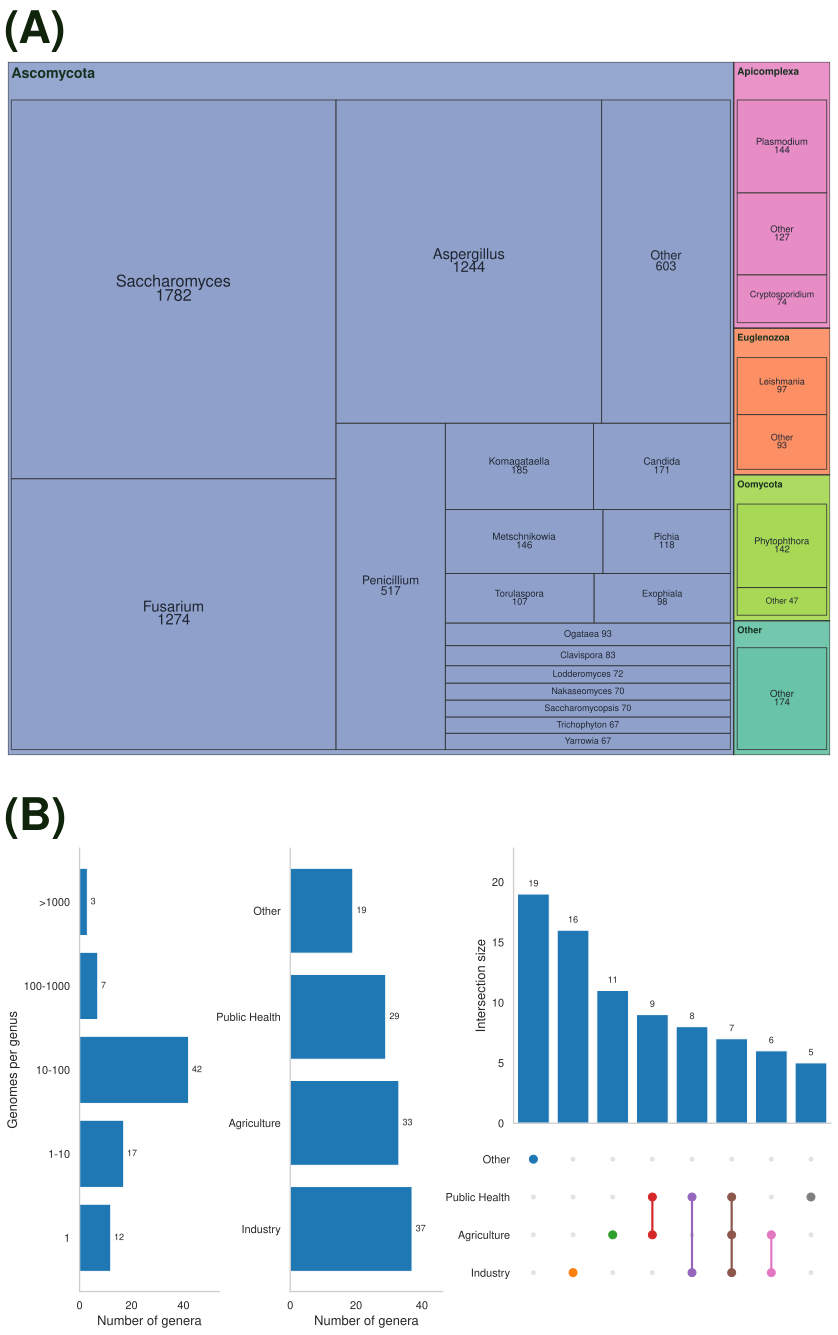

Wrote /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/assets/figures/fig-1.svg
Wrote /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/assets/figures/fig-1.png


In [6]:
SVG_NS = "http://www.w3.org/2000/svg"
XLINK_NS = "http://www.w3.org/1999/xlink"
ET.register_namespace("", SVG_NS)
ET.register_namespace("xlink", XLINK_NS)


def load_svg(path, prefix):
    root = ET.parse(path).getroot()
    view_box = root.get("viewBox")
    if view_box is None:
        raise ValueError(f"Missing viewBox: {path}")
    x, y, width, height = map(float, view_box.split())
    panel = copy.deepcopy(root)
    id_map = {}
    for element in panel.iter():
        old_id = element.get("id")
        if old_id:
            new_id = f"{prefix}_{old_id}"
            id_map[old_id] = new_id
            element.set("id", new_id)
    for element in panel.iter():
        for key, value in list(element.attrib.items()):
            for old_id, new_id in id_map.items():
                value = value.replace(f"url(#{old_id})", f"url(#{new_id})")
                if value == f"#{old_id}":
                    value = f"#{new_id}"
            element.set(key, value)
        if element.tag == f"{{{SVG_NS}}}style" and element.text:
            for old_id, new_id in id_map.items():
                element.text = re.sub(
                    rf"#{re.escape(old_id)}(?![\w.-])",
                    f"#{new_id}",
                    element.text,
                )
    return panel, (x, y, width, height)


def nested_svg(panel, view_box, x, y, width, height):
    source_x, source_y, source_width, source_height = view_box
    nested = ET.Element(
        f"{{{SVG_NS}}}svg",
        {
            "x": f"{x:.6f}",
            "y": f"{y:.6f}",
            "width": f"{width:.6f}",
            "height": f"{height:.6f}",
            "viewBox": (
                f"{source_x:g} {source_y:g} "
                f"{source_width:g} {source_height:g}"
            ),
            "preserveAspectRatio": "xMidYMid meet",
        },
    )
    for child in panel:
        nested.append(copy.deepcopy(child))
    return nested


treemap_svg, treemap_box = load_svg(FIGURES_DIR / "treemap.svg", "treemap")
upset_svg, upset_box = load_svg(FIGURES_DIR / "upset.svg", "upset")

width = max(treemap_box[2], upset_box[2])
treemap_height = treemap_box[3] * width / treemap_box[2]
upset_height = upset_box[3] * width / upset_box[2]
gap = 24.0
label_height = 54.0
treemap_y = label_height
upset_label_y = treemap_y + treemap_height + gap
upset_y = upset_label_y + label_height
height = upset_y + upset_height

root = ET.Element(
    f"{{{SVG_NS}}}svg",
    {
        "width": f"{width:.6f}pt",
        "height": f"{height:.6f}pt",
        "viewBox": f"0 0 {width:.6f} {height:.6f}",
        "version": "1.1",
    },
)
ET.SubElement(
    root,
    f"{{{SVG_NS}}}rect",
    {
        "x": "0",
        "y": "0",
        "width": "100%",
        "height": "100%",
        "fill": "white",
    },
)
root.append(nested_svg(treemap_svg, treemap_box, 0, treemap_y, width, treemap_height))
root.append(nested_svg(upset_svg, upset_box, 0, upset_y, width, upset_height))

for label, y in (("(A)", 43.0), ("(B)", upset_label_y + 43.0)):
    text = ET.SubElement(
        root,
        f"{{{SVG_NS}}}text",
        {
            "x": "4",
            "y": f"{y:.6f}",
            "font-family": "Nimbus Sans, Arial, Helvetica, sans-serif",
            "font-size": "45",
            "font-weight": "bold",
            "fill": "#10230b",
        },
    )
    text.text = label

figure1_svg = OUTPUT_DIR / "fig-1.svg"
figure1_png = OUTPUT_DIR / "fig-1.png"
ET.indent(root)
ET.ElementTree(root).write(
    figure1_svg,
    encoding="utf-8",
    xml_declaration=True,
)

converter = shutil.which("magick") or shutil.which("convert")
if converter is None:
    raise RuntimeError("ImageMagick is required to create the PNG output")
command = [converter]
if Path(converter).name == "magick":
    command.append("convert")
command.extend(
    [
        "-density",
        "300",
        str(figure1_svg),
        "-background",
        "white",
        "-alpha",
        "remove",
        "-alpha",
        "off",
        "-units",
        "PixelsPerInch",
        "-density",
        "300",
        "-strip",
        f"PNG24:{figure1_png}",
    ]
)
subprocess.run(command, check=True)
figure1_panel_directory.cleanup()

display(SVG(filename=str(figure1_svg)))
print(f"Wrote {figure1_svg}")
print(f"Wrote {figure1_png}")
